In [1]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging/deep_hedging


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader

from src.models.gbm import simulate_gbm
from src.derivatives.european_call import black_scholes_call, black_scholes_delta
from src.strategies.delta_hedge import run_delta_hedge
from src.strategies.neural_hedge import NeuralHedge
from src.portfolio import run_hedge_torch
from src.metrics import mse_hedging_loss

In [3]:
DTYPE = torch.float32
SEED = 123

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cpu")

print("device:", device)

device: mps


In [4]:
# experiment params

S0 = 100.0
K = 100.0

sigma = 0.20

r = 0.0
T = 1.0

n_steps = 52

transaction_cost_rate = 0.0


# training params

n_train = 50_000
n_val = 10_000
n_test = 50_000

batch_size = 1024

n_epochs = 50

learning_rate = 1e-3

In [5]:
train_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_train,
    r=r,
    seed=123
).spot

val_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_val,
    r=r,
    seed=456
).spot

test_paths_np = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_test,
    r=r,
    seed=789
).spot

print(train_paths_np.shape)
print(val_paths_np.shape)
print(test_paths_np.shape)

(50000, 53)
(10000, 53)
(50000, 53)


In [6]:
train_spot = torch.tensor(train_paths_np, dtype=DTYPE)
val_spot = torch.tensor(val_paths_np, dtype=DTYPE)
test_spot = torch.tensor(test_paths_np, dtype=DTYPE)

train_dataset = TensorDataset(train_spot)
val_dataset = TensorDataset(val_spot)
test_dataset = TensorDataset(test_spot)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
premium = black_scholes_call(
    S=S0,
    K=K,
    sigma=sigma,
    T=T,
    t=0.0,
    r=r
)

print("initial call premium:", premium)

initial call premium: 7.965567455405804


In [8]:
def neural_pnl(model, spot_batch):
    """
    run neural hedge on one minibatch

    returns
    -------
    pnl : tensor
        shape (batch_size,)
    """

    spot_batch = spot_batch.to(device=device, dtype=DTYPE)

    # gbm has constant variance
    variance_batch = torch.full_like(spot_batch, sigma**2)

    pnl, transaction_costs = run_hedge_torch(
        model=model,
        spot_paths=spot_batch,
        variance_paths=variance_batch,
        K=K,
        T=T,
        premium=premium,
        r=r,
        transaction_cost_rate=transaction_cost_rate
    )

    return pnl

In [9]:
model = NeuralHedge().to(device)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

NeuralHedge(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer
):
    model.train()

    total_squared_error = 0.0
    total_samples = 0

    for (spot_batch,) in loader:
        optimizer.zero_grad()

        pnl = neural_pnl(model, spot_batch)

        loss = mse_hedging_loss(pnl)
        loss.backward()
        optimizer.step()

        batch_n = spot_batch.shape[0]

        total_squared_error += loss.item() * batch_n
        total_samples += batch_n

    return total_squared_error / total_samples

In [11]:
@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()

    total_squared_error = 0.0
    total_samples = 0

    for (spot_batch,) in loader:
        pnl = neural_pnl(model, spot_batch)

        loss = mse_hedging_loss(pnl)

        batch_n = spot_batch.shape[0]

        total_squared_error += loss.item() * batch_n
        total_samples += batch_n

    return total_squared_error / total_samples

In [12]:
history = []

best_val_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss = evaluate_loss(model, val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f}")

model.load_state_dict(best_state)
print("best validation loss:", best_val_loss)

epoch 001 | train=79.187880 | val=22.575065
epoch 005 | train=2.004157 | val=1.856023
epoch 010 | train=1.379580 | val=1.348777
epoch 015 | train=1.196795 | val=1.164075
epoch 020 | train=1.108441 | val=1.087383
epoch 025 | train=1.069116 | val=1.052761
epoch 030 | train=1.044293 | val=1.029165
epoch 035 | train=1.021142 | val=1.004766
epoch 040 | train=1.001009 | val=0.987808
epoch 045 | train=0.990004 | val=0.978801
epoch 050 | train=0.986402 | val=0.967009
best validation loss: 0.9670094563484192


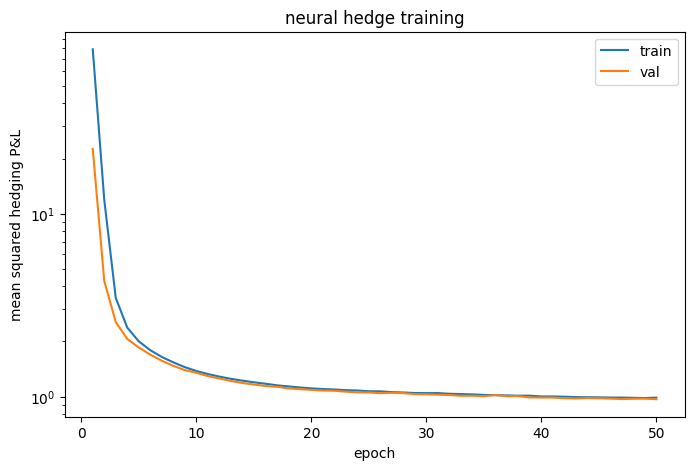

In [13]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")

plt.yscale("log")

plt.xlabel("epoch")
plt.ylabel("mean squared hedging P&L")
plt.title("neural hedge training")
plt.legend()

plt.show()

In [14]:
@torch.no_grad()
def collect_pnl(model, loader):
    model.eval()

    pnl_batches = []

    for (spot_batch,) in loader:
        pnl = neural_pnl(model, spot_batch)
        pnl_batches.append(pnl.cpu())

    return torch.cat(pnl_batches).numpy()

In [15]:
nn_pnl = collect_pnl(model, test_loader)

nn_pnl.shape

(50000,)

# black-scholes delta benchmark

In [16]:
bs_result = run_delta_hedge(
    stock_paths=test_paths_np,
    K=K,
    sigma=sigma,
    T=T,
    r=r,
    transaction_cost_rate=transaction_cost_rate,
    record_history=False
)

bs_pnl = bs_result["pnl"]

In [17]:
def pnl_metrics(pnl):
    pnl = np.asarray(pnl)

    return {
        "mean": np.mean(pnl),
        "std": np.std(pnl, ddof=1),
        "rmse": np.sqrt(np.mean(pnl**2)),
        "q05": np.quantile(pnl, 0.05),
        "q01": np.quantile(pnl, 0.01)
    }

In [18]:
comparison = pd.DataFrame({
    "black-scholes delta": pnl_metrics(bs_pnl),
    "neural hedge": pnl_metrics(nn_pnl)
}).T

comparison

,mean,std,rmse,q05,q01
black-scholes delta,0.000034,0.951395,0.951385,-1.552763,-2.599678
neural hedge,0.002164,0.982804,0.982796,-1.610281,-2.702585


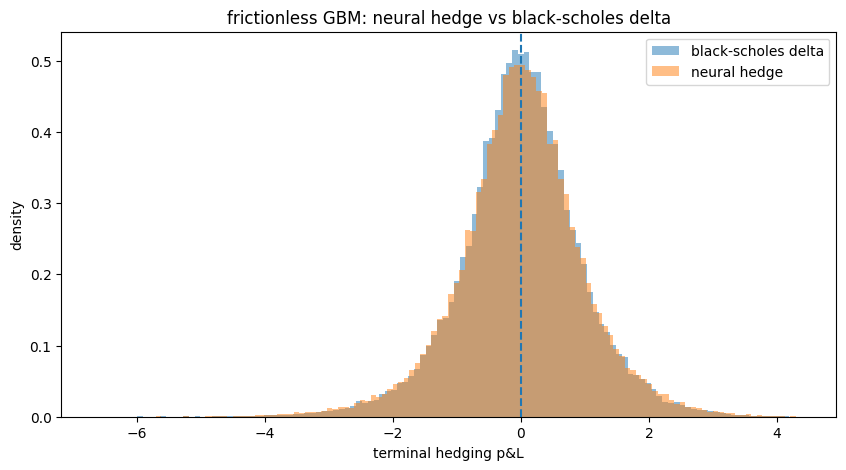

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(
    bs_pnl,
    bins=120,
    density=True,
    alpha=0.5,
    label="black-scholes delta"
)

plt.hist(
    nn_pnl,
    bins=120,
    density=True,
    alpha=0.5,
    label="neural hedge"
)

plt.axvline(0, linestyle="--")

plt.xlabel("terminal hedging p&L")
plt.ylabel("density")
plt.title("frictionless GBM: neural hedge vs black-scholes delta")

plt.legend()

plt.show()

In [20]:
S_grid_np = np.linspace(70, 130, 300)
S_grid = torch.tensor(S_grid_np, dtype=DTYPE, device=device)

t_eval = 0.5
tau_normalized = (T - t_eval) / T

with torch.no_grad():
    log_moneyness = torch.log(S_grid / K)
    variance_feature = torch.full_like(S_grid, sigma**2 / 0.04)
    tau_feature = torch.full_like(S_grid, tau_normalized)
    previous_position = torch.full_like(S_grid, 0.5)

    state = torch.stack([
        log_moneyness,
        variance_feature,
        tau_feature,
        previous_position
    ], dim=1)

    nn_delta = model(state).cpu().numpy()

bs_delta = black_scholes_delta(
    S=S_grid_np,
    K=K,
    sigma=sigma,
    T=T,
    t=t_eval,
    r=r
)

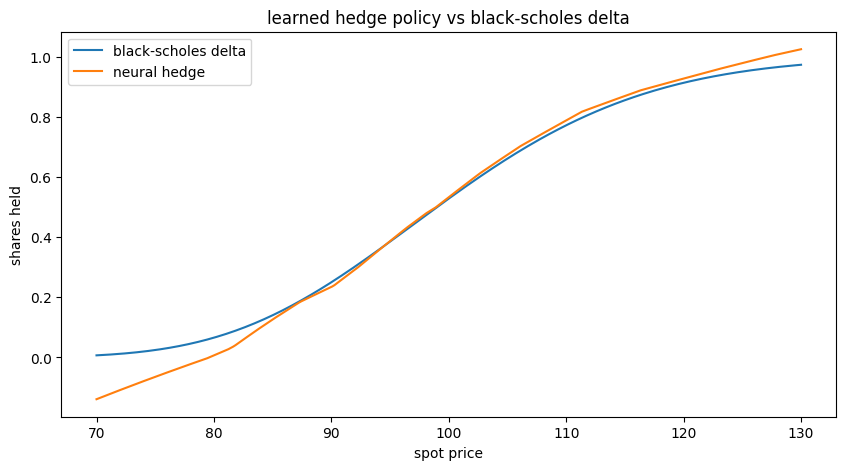

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(S_grid_np, bs_delta, label="black-scholes delta")
plt.plot(S_grid_np, nn_delta, label="neural hedge")

plt.xlabel("spot price")
plt.ylabel("shares held")
plt.title("learned hedge policy vs black-scholes delta")

plt.legend()

plt.show()

In [22]:
spot_batch = next(
    iter(train_loader)
)[0].to(device)

optimizer.zero_grad()

pnl = neural_pnl(
    model,
    spot_batch,
)

loss = mse_hedging_loss(pnl)

loss.backward()

for name, param in model.named_parameters():

    if param.grad is None:
        print(
            name,
            "NO GRADIENT"
        )

    else:
        print(
            name,
            param.grad.norm().item()
        )

network.0.weight 5.444340705871582
network.0.bias 3.877382755279541
network.2.weight 4.9356207847595215
network.2.bias 1.7376412153244019
network.4.weight 4.843680381774902
network.4.bias 2.269526720046997
